# Tutorial 1: Compute pathway signatures

### 📘 Overview

This notebook runs DESeq2 to compute differential expression results and performs pathway enrichment analysis with WikiPathways gene sets, producing –log₁₀ *p*-values that quantify pathway activation for each compound.

**Inputs**  
Raw gene expression count matrix

**Output**  
- An AnnData file with DESeq2 differential expression results (log₂ fold changes, adjusted p-values)
- An AnnData file with WikiPathways signatures (–log₁₀ *p*-values)

In [1]:
%%capture

!conda install -c bioconda gseapy

In [2]:
import numpy as np
import pandas as pd
import anndata as ad

import matplotlib.pyplot as plt
import seaborn as sns

import dilimap as dmap

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
dmap.logging.print_version()

Running dilimap 0.2.dev20+gc285bd842 (python 3.10.19) on 2025-11-20 00:23.


## 1. Prepare data

* We load raw RNA-seq count data generated from the lab.
* The demo dataset includes primary human hepatocytes treated with 5 compounds.
* Each compound tested at 4 concentrations to capture dose-dependent transcriptional responses.

In [5]:
adata = dmap.datasets.demo_data(level='counts')

Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [6]:
## Simplify keys

adata.obs.rename(
    columns={'CONCENTRATION_UM': 'dose_uM', 'COMPOUND': 'compound_name'}, inplace=True
)

In [7]:
## Define dose levels

adata.obs['dose_level'] = 'Control'
labels = ['Low', 'Middle', 'Mid-High', 'High']

for cmpd in adata.obs['compound_name'].dropna().unique():
    if 'DMSO' in cmpd:
        continue

    idx = adata.obs['compound_name'] == cmpd
    levels = sorted(set(adata.obs['dose_uM'][idx]) - {14.10})  # remove 14.10 from DMSO

    for label, lvl in zip(labels, levels):
        adata.obs.loc[idx & (adata.obs['dose_uM'] == lvl), 'dose_level'] = label

adata.obs['dose_level'] = pd.Categorical(
    adata.obs['dose_level'], categories=['Control'] + labels, ordered=True
)

In [8]:
## Define auxiliary columns

adata.obs['cmpd_dose'] = (
    adata.obs['compound_name'].astype(str) + '_' + adata.obs['dose_level'].astype(str)
)
adata.obs['cmpd_dose_plate'] = (
    adata.obs['cmpd_dose'] + '_' + adata.obs['PLATE_NAME'].astype(str)
)
adata.obs_names = (
    adata.obs['PLATE_NAME'].astype(str)
    + '_'
    + adata.obs['LIBRARY_ID'].str.split('_').str[-1]
)

In [9]:
# Show compound x dose with number of replicates

dmap.utils.crosstab(adata, ['compound_name', 'dose_level'])

dose_level,Control,Low,Middle,Mid-High,High
compound_name,,,,,
Almotriptan,0,3,3,3,3
Brompheniramine,0,3,3,3,3
Chlorpromazine,0,4,0,0,0
DMSO,8,0,0,0,0
DMSO_replaced,24,0,0,0,0
Darunavir,0,3,3,3,3
Tolvaptan,0,3,3,3,3


In [10]:
# Platemap

from dilimap.utils import platemap

adata.obs['WELL_ROW'] = adata.obs['WELL_ID'].str[0]
adata.obs['WELL_COL'] = adata.obs['WELL_ID'].str[1:]

CMPD_COLOR = (
    adata.obs['compound_name']
    .map(
        {
            'DMSO': 'seashell',
            'DMSO_replaced': 'seashell',
            'Chlorpromazine': 'lightsalmon',
        }
    )
    .fillna('lightblue')
)
CMPD_COLOR_OPACITY = '; opacity: ' + adata.obs['dose_level'].astype(str).map(
    {'Control': '1', 'Low': '.4', 'Middle': '.6', 'Mid-High': '.8', 'High': '1'}
)


def highlight_cells(x):
    return (
        'background-color: '
        + x.map(dict(zip(adata.obs['CMPD_DOSE'], CMPD_COLOR))).fillna('white')
        + x.map(dict(zip(adata.obs['CMPD_DOSE'], CMPD_COLOR_OPACITY)))
    )


df_cmpd_map = platemap(adata, value_key='cmpd_dose', batch='PLATE_NAME')

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df_cmpd_map.index.str.endswith(('A', 'D', 'G')), df_cmpd_map.columns),
    **{'border-top': '1.5pt solid black'},
)

display(
    df_cmpd_map.style.apply(highlight_cells)
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

,1,2,3,4,5,6,7,8,9,10,11,12
A1_M4_S8_A,Darunavir_High,Darunavir_Mid-High,Darunavir_Middle,Darunavir_Low,Almotriptan_High,Almotriptan_Mid-High,Almotriptan_Middle,Almotriptan_Low,Brompheniramine_High,Brompheniramine_Mid-High,Brompheniramine_Middle,Brompheniramine_Low
A1_M4_S8_B,Darunavir_High,Darunavir_Mid-High,Darunavir_Middle,Darunavir_Low,Almotriptan_High,Almotriptan_Mid-High,Almotriptan_Middle,Almotriptan_Low,Brompheniramine_High,Brompheniramine_Mid-High,Brompheniramine_Middle,Brompheniramine_Low
A1_M4_S8_C,Darunavir_High,Darunavir_Mid-High,Darunavir_Middle,Darunavir_Low,Almotriptan_High,Almotriptan_Mid-High,Almotriptan_Middle,Almotriptan_Low,Brompheniramine_High,Brompheniramine_Mid-High,Brompheniramine_Middle,Brompheniramine_Low
A1_M4_S8_D,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,Tolvaptan_High,Tolvaptan_Mid-High,Tolvaptan_Middle,Tolvaptan_Low,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control
A1_M4_S8_E,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,Tolvaptan_High,Tolvaptan_Mid-High,Tolvaptan_Middle,Tolvaptan_Low,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control
A1_M4_S8_F,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,Tolvaptan_High,Tolvaptan_Mid-High,Tolvaptan_Middle,Tolvaptan_Low,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control,DMSO_replaced_Control
A1_M4_S8_G,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,DMSO_Control,Chlorpromazine_Low,Chlorpromazine_Low,Chlorpromazine_Low,Chlorpromazine_Low


## 2. Quality-control

Next, we applied the following QC filtering to retain high-quality wells:

1.	Total RNA counts > mean - 2.5 standard deviations (~700k total counts)
2.	Mitochondrial RNA fraction < 9%
3.	Correlation between replicates > 0.99

In [11]:
# QC flags from viability screen

adata.obs['ldh_qc_pass'] = (adata.obs['LDH_QC'] == '') & (
    adata.obs['compound_name'] != 'DMSO_replaced'
)

In [12]:
# QC of total counts and mtRNA

dmap.pp.qc_metrics(adata)

thresh_counts = (
    np.median(adata.obs['log_totalRNA']) - 2.5 * adata.obs['log_totalRNA'].std()
)
adata.obs['rna_qc_pass'] = (adata.obs['log_totalRNA'] > thresh_counts) & (
    adata.obs['pct_mtRNA'] < 9
)

Added the following to `adata.obs`: ['log_totalRNA', 'pct_mtRNA', 'pct_rRNA']


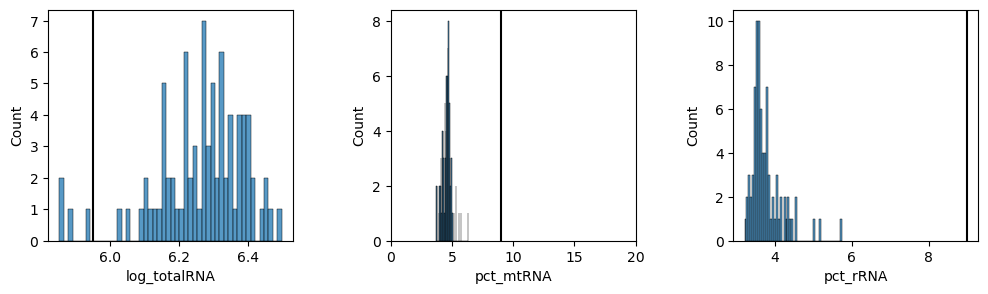

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={'wspace': 0.4})

sns.histplot(adata.obs['log_totalRNA'], bins=50, ax=axs[0])
sns.histplot(adata.obs['pct_mtRNA'], bins=50, ax=axs[1])
sns.histplot(adata.obs['pct_rRNA'], bins=50, ax=axs[2])

axs[1].set_xlim(0, 20)

axs[0].axvline(thresh_counts, c='k')
axs[1].axvline(9, c='k')
axs[2].axvline(9, c='k')

plt.show()

In [14]:
## Example plate with QC metrics


def color_boolean(val):
    return 'color: lightred; font-weight: bold' if val else ''


for val in ['log_totalRNA', 'pct_mtRNA']:
    print(f'\n\033[1m{val}')

    df = platemap(adata, val, batch='PLATE_NAME')
    qc_fail = ~platemap(adata, 'rna_qc_pass', batch='PLATE_NAME').astype(bool)

    styler = df.style.format(precision=2)

    if val != 'notes_flags':
        mu, std = np.median(adata.obs[val]), np.std(adata.obs[val])
        styler = styler.background_gradient(
            vmin=mu - 3 * std, vmax=mu + 3 * std, cmap='RdBu_r'
        )

    styler = (
        styler.apply(lambda c: qc_fail[c.name].apply(color_boolean))
        .map(lambda x: 'background-color: white' if pd.isnull(x) else '')
        .set_properties(**col_borders)
        .set_properties(**row_borders)
    )

    display(styler)


log_totalRNA


,1,2,3,4,5,6,7,8,9,10,11,12
A1_M4_S8_A,6.22,6.28,5.86,5.89,6.21,6.11,6.35,6.27,6.27,6.15,6.16,6.10
A1_M4_S8_B,6.35,6.38,6.29,6.39,6.13,6.03,6.50,6.16,6.33,5.93,6.32,5.85
A1_M4_S8_C,6.16,6.36,6.41,6.34,6.32,6.21,6.45,6.27,6.40,6.22,6.38,6.19
A1_M4_S8_D,6.39,6.41,6.37,6.38,6.31,6.20,6.16,6.24,6.35,6.31,6.45,6.24
A1_M4_S8_E,6.30,6.40,6.33,6.32,6.27,6.22,6.18,6.16,6.05,6.27,6.29,6.16
A1_M4_S8_F,6.09,6.24,6.29,6.30,6.21,6.24,6.39,6.28,6.30,6.27,6.16,6.26
A1_M4_S8_G,6.41,6.36,6.34,6.46,6.32,6.39,6.45,6.24,6.30,6.38,6.22,6.11



pct_mtRNA


,1,2,3,4,5,6,7,8,9,10,11,12
A1_M4_S8_A,3.71,4.21,6.34,5.58,4.93,4.28,4.57,4.45,4.47,4.76,4.65,4.93
A1_M4_S8_B,4.19,4.61,4.66,4.62,5.33,4.10,4.33,4.68,4.85,4.89,4.06,4.42
A1_M4_S8_C,3.78,4.44,4.70,4.81,4.77,4.50,4.55,4.26,4.68,4.66,4.22,4.31
A1_M4_S8_D,4.37,4.70,4.79,4.71,4.53,4.56,5.06,4.71,4.52,4.25,4.02,3.96
A1_M4_S8_E,4.72,4.71,4.58,5.29,4.71,4.56,5.72,4.63,5.16,4.57,4.32,4.42
A1_M4_S8_F,4.72,4.59,4.72,4.84,4.79,4.22,4.42,4.17,4.10,4.02,4.25,3.78
A1_M4_S8_G,4.75,4.68,4.88,4.52,4.92,4.64,4.77,4.43,4.10,3.72,4.83,4.06


In [15]:
# QC of cross-replicate correlation

dmap.pp.qc_cross_rep_correlation(adata, group_key='cmpd_dose', plate_key='PLATE_NAME')

Added the following to `adata.obs`: ['cross_rep_correlation', 'rep_corr_qc_pass']


In [16]:
## Example plate with cross-replicate correlations

val = 'cross_rep_correlation'

df = platemap(adata, val, batch='PLATE_NAME')
df_bool = np.invert(
    platemap(adata, 'rep_corr_qc_pass', batch='PLATE_NAME').fillna(False).astype(bool)
)
mu, std = np.nanmean(adata.obs[val]), np.nanstd(adata.obs[val])

col_borders = dict(subset=['4', '8'], **{'border-right': '1.5pt solid black'})
row_borders = dict(
    subset=(df.index.str.endswith(('A', 'D', 'G')), df.columns),
    **{'border-top': '1.5pt solid black'},
)

print(val, f'CI=[{mu - 2 * std:0.3f},{1}]')
display(
    df.style.format(precision=3)
    .background_gradient(vmin=mu - 5 * std, vmax=1, cmap='Reds_r')
    .apply(lambda c: df_bool[c.name].apply(color_boolean))
    .map(lambda x: 'background-color: white' if pd.isnull(x) else '')
    .set_properties(**col_borders)
    .set_properties(**row_borders)
)

cross_rep_correlation CI=[0.982,1]


,1,2,3,4,5,6,7,8,9,10,11,12
A1_M4_S8_A,0.987,0.996,0.981,0.986,0.997,0.999,0.999,0.999,0.999,0.996,0.998,0.989
A1_M4_S8_B,0.995,0.999,0.998,0.999,0.997,0.997,0.999,0.999,0.999,0.999,0.999,0.999
A1_M4_S8_C,0.995,0.999,0.998,0.999,0.996,0.999,0.999,0.999,0.999,0.999,0.999,0.999
A1_M4_S8_D,0.995,0.996,0.997,0.996,0.995,0.998,0.999,0.999,0.995,0.991,0.987,0.968
A1_M4_S8_E,0.997,0.996,0.997,0.995,0.993,0.994,0.999,0.999,0.995,0.997,0.995,0.995
A1_M4_S8_F,0.995,0.996,0.994,0.994,0.995,0.998,0.999,0.999,0.995,0.990,0.970,0.958
A1_M4_S8_G,0.996,0.996,0.996,0.990,0.998,0.997,0.997,0.997,0.993,0.997,0.997,0.997


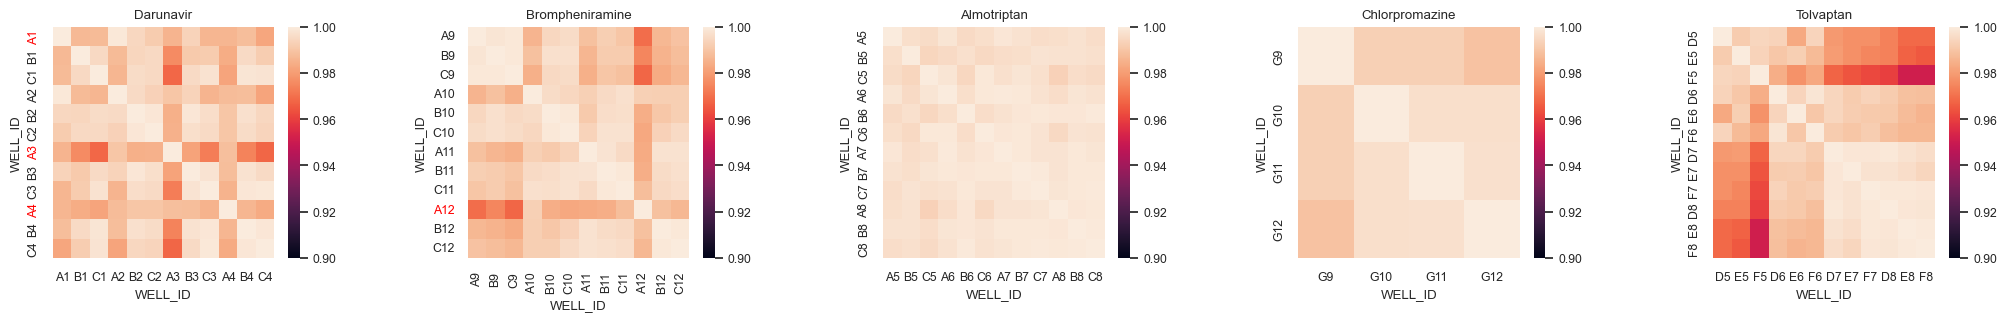

In [17]:
from natsort import index_natsorted

sns.set(font_scale=0.8)

df_cmpd_flags = adata.obs[~adata.obs['rep_corr_qc_pass']][
    'compound_name'
].value_counts()
df_cmpd_flags = df_cmpd_flags[~df_cmpd_flags.index.str.contains('DMSO')]
cmpd_flags = df_cmpd_flags.index[:8]

fig, axs = plt.subplots(
    1, len(cmpd_flags), figsize=(5 * len(cmpd_flags), 3), gridspec_kw={'wspace': 0.5}
)
for i, cmpd_name in enumerate(cmpd_flags):
    df_sub = adata[adata.obs['compound_name'] == cmpd_name].to_df()
    df_sub.index = adata[adata.obs['compound_name'] == cmpd_name].obs['WELL_ID']

    df_sub_corr = df_sub.T.corr()
    idx_sort = index_natsorted(df_sub_corr.index.str[1:] + df_sub_corr.index.str[0])
    df_sub_corr = df_sub_corr.iloc[idx_sort, idx_sort]

    g = sns.heatmap(df_sub_corr, vmax=1, vmin=0.9, yticklabels=True, ax=axs[i])

    flagged = (
        adata[
            (adata.obs['compound_name'] == cmpd_name) & ~adata.obs['rep_corr_qc_pass']
        ]
        .obs['WELL_ID']
        .values
    )
    for label in g.get_yticklabels():
        if label.get_text() in flagged:
            label.set_color('red')

    axs[i].set_title(cmpd_name)

## 3. DESeq2

* Samples passing the above QC filters are used to compute differential expression signatures with DESeq2.
* The differential test compares compound-treated cells vs. DMSO controls from the same plate.
* To streamline the workflow, DESeq2 runs via an R script inside a Docker container, so there is no need to switch between Python and R. Ensure Docker is installed (https://www.docker.com/products/docker-desktop/); the initial build may take a few minutes. Alternatively, you can run DESeq2 natively in R if preferred.
* If the Docker image is unavailable, the code will fall back to using a precomputed DESeq2 file.

In [18]:
%%capture

from dask.distributed import LocalCluster, Client

cluster = LocalCluster(n_workers=4, threads_per_worker=1, memory_limit='auto')
client = Client(cluster)

In [19]:
import warnings

try:
    adatas = {}

    for plate in np.unique(adata.obs['PLATE_NAME']):
        adata_batch = adata[adata.obs['PLATE_NAME'] == plate].copy()
        adata_batch = adata_batch[
            (
                adata_batch.obs['ldh_qc_pass']
                & adata_batch.obs['rna_qc_pass']
                & adata_batch.obs['rep_corr_qc_pass']
            )
        ].copy()

        adata_batch.obs_names_make_unique()

        adatas[plate] = dmap.pp.deseq2(
            adata_batch,
            pert_name_col='compound_name',
            other_pert_cols=['dose_level'],
            dask_client=client,
        )

        adatas[plate].obs['PLATE_NAME'] = plate

    adata_deseq = ad.concat(adatas.values(), join='outer')

except Exception as e:
    warnings.warn(
        'Falling back to precomputed DESeq2 data because Docker is not available or not running.\n'
        'To run DESeq2 natively, ensure Docker is installed and the daemon is active.\n'
        f'Original error: {str(e)}'
    )

    adata_deseq = dmap.datasets.demo_data(level='deseq2')

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_46456/1951114027.py:30: UserWarning: Falling back to precomputed DESeq2 data because Docker is not available or not running.
To run DESeq2 natively, ensure Docker is installed and the daemon is active.
Original error: Docker is installed but cannot connect to the Docker daemon.
Please ensure the Docker application is running and try again.
Details: ERROR: Cannot connect to the Docker daemon at unix:///Users/callustang/.docker/run/docker.sock. Is the docker daemon running?
errors pretty printing info
  warnings.warn(


Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [20]:
adata_deseq = adata_deseq[~np.all(adata_deseq.to_df('LFC').isna(), 1)].copy()

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [21]:
adata_deseq.obs['ldh_qc_pass'] = adata_deseq.obs['ldh_qc_pass'].astype(bool)
adata_deseq.obs['rna_qc_pass'] = adata_deseq.obs['rna_qc_pass'].astype(bool)
adata_deseq.obs['rep_corr_qc_pass'] = adata_deseq.obs['rep_corr_qc_pass'].astype(bool)

## 4. WikiPathways

* Next, we compute pathway signatures by performing enrichment analysis on differentially expressed genes (DEGs). Using the hypergeometric test, we calculate how likely it is that a pathway is enriched with DEGs by chance.
* We adjust p-values for multiple testing (FDR) and apply a -log10 transformation to derive pathway signatures. These -log10(FDR) values serve as robust, quantitative features for our model.

In [22]:
FDR = adata_deseq.to_df('FDR')  # adjusted p-values from DESeq2

In [24]:
adata_wiki = dmap.pp.pathway_signatures(FDR)

Attempt 1 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 2 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 3 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 4 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 5 failed with error: enrichr() got an unexpected keyword argument 'organism'
Failed after 5 attempts for index 1.
Attempt 1 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 2 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 3 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 4 failed with error: enrichr() got an unexpected keyword argument 'organism'
Attempt 5 failed with error: enrichr() got an unexpected keyword argument 'organism'
Failed after 5 attempts for index 2.
Attempt 1 failed with error: enrichr() got an unexpected keyword argument 'o

KeyError: 'obs_index'

In [ ]:
adata_wiki.obs = adata_deseq.obs.copy()

In [ ]:
adata_wiki.X = np.nan_to_num(adata_wiki.X)

## Push

* Here, the data is uploaded to S3, which requires appropriate access permissions.
* Instead, you can save it locally and load it in the next tutorial notebook to run DILI predictions.

In [ ]:
# dmap.s3.write(adata_deseq, 'demo_data_deseq2.h5ad')

In [ ]:
# dmap.s3.write(adata_wiki, 'demo_data_pathways.h5ad')